# ASOS 1-Minute Data Pipeline

Fetch TRUE per-minute precipitation and weather data from ASOS stations via IEM.

**Source:** https://mesonet.agron.iastate.edu/request/asos/1min.phtml

## Key Features
- 1-min `precip` = TRUE precipitation per minute (not hourly running totals)
- Flexible resampling to any interval (5min, 10min, 15min, 1H, etc.)
- Precipitation type classification (rain, snow, freezing rain, etc.)

## Pipeline Steps
1. Fetch raw 1-minute data (monthly chunks)
2. Convert to metric units
3. Resample to desired interval
4. Analyze precipitation types
5. Plot and save results

In [17]:
# Cell 1: Setup
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from asos_functions import (
    STATIONS,
    fetch_all_stations_1min,
    process_all_stations,
    resample_all_stations,
    compute_accumulated_all,
    get_precip_type_summary,
    filter_by_precip_type,
    save_data,
    plot_precipitation_subplots,
    plot_weather_subplots,
    plot_accumulated,
    plot_precip_by_type
)

import matplotlib.pyplot as plt
import pandas as pd

# CONFIG
STATION_IDS = ['JFK', 'LGA', 'NYC']
START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2024, 1, 30)
OUTPUT_DIR = Path('../../data/noaa_asos')

print(f'Stations: {STATION_IDS}')
print(f'Period: {START_DATE.date()} to {END_DATE.date()}')
print('✓ Setup complete')

Stations: ['JFK', 'LGA', 'NYC']
Period: 2024-01-01 to 2024-01-30
✓ Setup complete


In [18]:
import requests
from io import StringIO
import pandas as pd

url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos1min.py"

# Test with original working vars
params = {
    'station': 'JFK',
    'tz': 'UTC',
    'year1': 2024, 'month1': 1, 'day1': 1,
    'year2': 2024, 'month2': 1, 'day2': 2,
    'vars': 'tmpf,dwpf,sknt,drct,precip',
    'sample': '1min',
    'what': 'download',
    'delim': 'comma',
}
response = requests.get(url, params=params, timeout=60)
print(f"Original vars - Status: {response.status_code}, Length: {len(response.text)}")

# Test with new vars
params['vars'] = 'tmpf,dwpf,sknt,drct,gust_sknt,gust_drct,ptype,precip'
response = requests.get(url, params=params, timeout=60)
print(f"New vars - Status: {response.status_code}, Length: {len(response.text)}")
print(f"Response: {response.text[:200]}")

Original vars - Status: 200, Length: 79948
New vars - Status: 200, Length: 92561
Response: station,station_name,valid(UTC),tmpf,dwpf,sknt,drct,gust_sknt,gust_drct,ptype,precip
JFK,NEW YORK/JF KENNEDY,2024-01-01 00:00,42,26,7,273,8,276,NP,0.0
JFK,NEW YORK/JF KENNEDY,2024-01-01 00:01,42,26,6,


In [19]:
# Cell 2: Fetch data (monthly chunks, merged)
raw_data = fetch_all_stations_1min(STATION_IDS, START_DATE, END_DATE)

FETCHING 1-MINUTE ASOS DATA
Period: 2024-01-01 to 2024-01-30

JFK (JFK Airport):
  2024-01... ✓ 40,240 rows
  ✓ Total: 40,240 rows

LGA (LaGuardia Airport):
  2024-01... ✓ 41,036 rows
  ✓ Total: 41,036 rows

NYC (Central Park):
  2024-01... ✓ 34,333 rows
  ✓ Total: 34,333 rows

✓ Fetched 3/3 stations


In [20]:
# Cell 3: Quick look at raw data
for station_id, df in raw_data.items():
    print(f"\n{station_id}:")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Shape: {df.shape}")
    print(f"  Date range: {df['valid'].min()} to {df['valid'].max()}")


JFK:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (40240, 12)
  Date range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00

LGA:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (41036, 12)
  Date range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00

NYC:
  Columns: ['station', 'station_name', 'valid(UTC)', 'tmpf', 'dwpf', 'sknt', 'drct', 'gust_sknt', 'gust_drct', 'ptype', 'precip', 'valid']
  Shape: (34333, 12)
  Date range: 2024-01-01 00:00:00 to 2024-01-29 23:59:00


In [21]:
# Cell 4: Convert to metric
processed_data = process_all_stations(raw_data)


Converting to metric...
  JFK: 40,240 rows, total precip = 147.3 mm
  LGA: 41,036 rows, total precip = 158.2 mm
  NYC: 34,333 rows, total precip = 105.7 mm
✓ Conversion complete



In [22]:
# Cell 5: Check data summary
print("Data Summary:")
print("-" * 50)
for station_id, df in processed_data.items():
    total_precip = df['precip_mm'].sum()
    rainy_mins = (df['precip_mm'] > 0).sum()
    avg_temp = df['temp_c'].mean()
    avg_wind = df['wind_speed_ms'].mean()
    # avg_vis = df['visibility_km'].mean()
    print(f"\n{station_id}:")
    print(f"  Precip: {total_precip:.1f} mm ({rainy_mins:,} rainy minutes)")
    print(f"  Temp: {avg_temp:.1f} °C (mean)")
    print(f"  Wind: {avg_wind:.1f} m/s (mean)")
    # print(f"  Visibility: {avg_vis:.1f} km (mean)")

Data Summary:
--------------------------------------------------

JFK:
  Precip: 147.3 mm (512 rainy minutes)
  Temp: 2.3 °C (mean)
  Wind: 5.9 m/s (mean)

LGA:
  Precip: 158.2 mm (502 rainy minutes)
  Temp: 2.9 °C (mean)
  Wind: 5.5 m/s (mean)

NYC:
  Precip: 105.7 mm (391 rainy minutes)
  Temp: 3.1 °C (mean)
  Wind: 3.2 m/s (mean)



Precipitation Type Summary:
--------------------------------------------------
station_id      JFK      LGA      NYC
type                                 
dry         32284.0  33276.0  25665.0
rain         3709.0   4335.0   3633.0
snow         1225.0   1510.0   1258.0
precip       1093.0   1167.0    664.0
missing      1929.0    748.0   3113.0

Percentages:
--------------------------------------------------
station_id   JFK   LGA   NYC
type                        
dry         80.2  81.1  74.8
rain         9.2  10.6  10.6
snow         3.0   3.7   3.7
precip       2.7   2.8   1.9
missing      4.8   1.8   9.1



(<Figure size 1400x1000 with 3 Axes>,
 array([<Axes: title={'center': 'JFK (JFK Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'LGA (LaGuardia Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'NYC (Central Park)'}, xlabel='Date', ylabel='Precip (mm)'>],
       dtype=object))

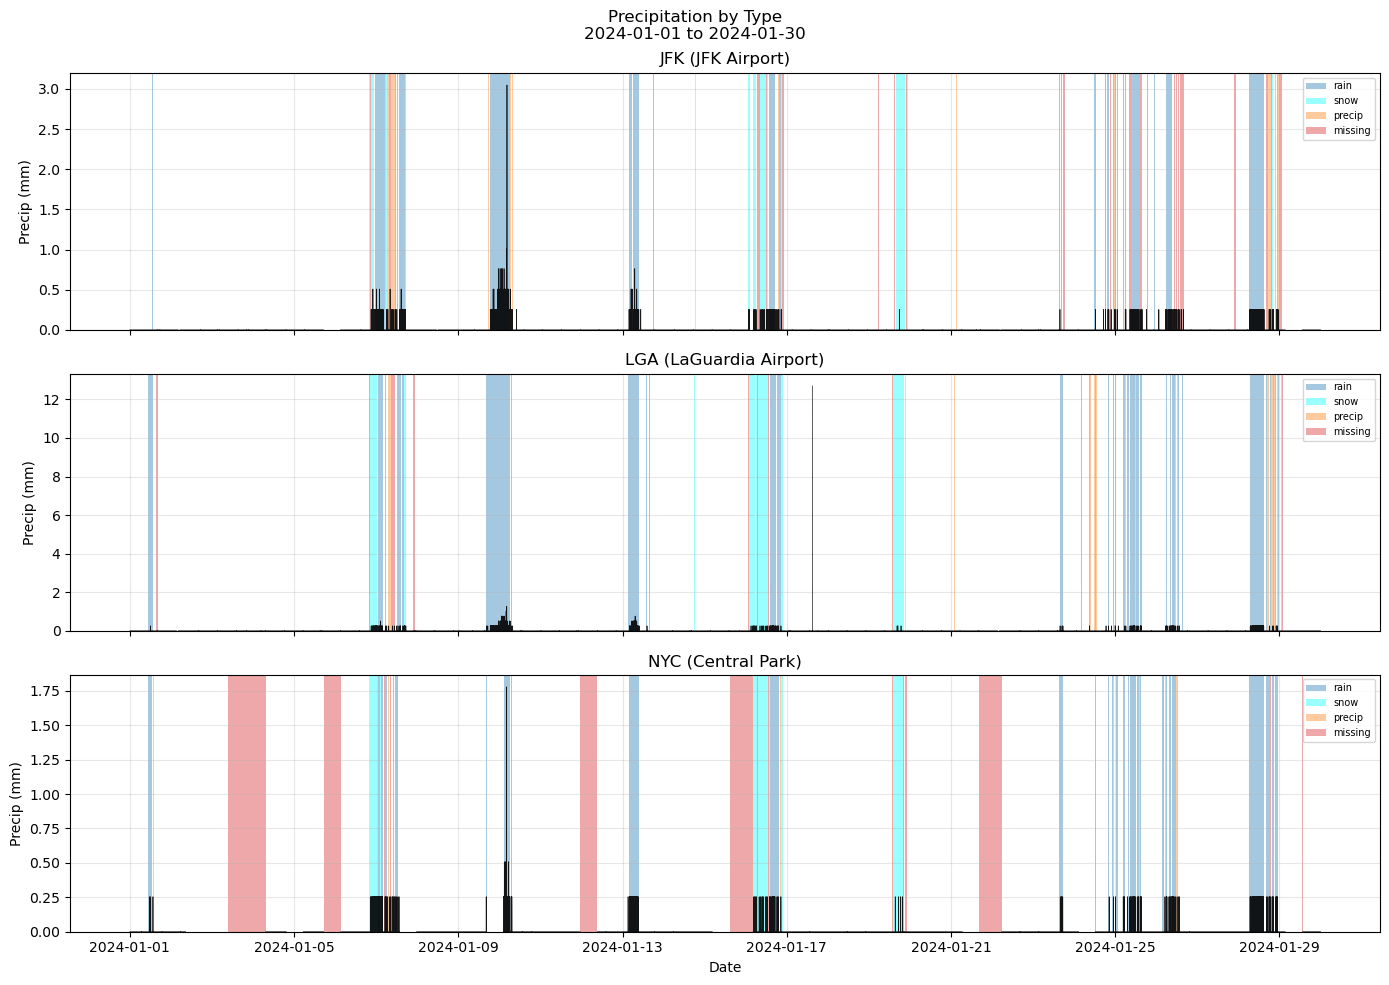

In [23]:

get_precip_type_summary(processed_data)
plot_precip_by_type(processed_data, start_date=START_DATE, end_date=END_DATE)

(<Figure size 1400x1000 with 3 Axes>,
 array([<Axes: title={'center': 'JFK (JFK Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'LGA (LaGuardia Airport)'}, ylabel='Precip (mm)'>,
        <Axes: title={'center': 'NYC (Central Park)'}, xlabel='Date', ylabel='Precip (mm)'>],
       dtype=object))

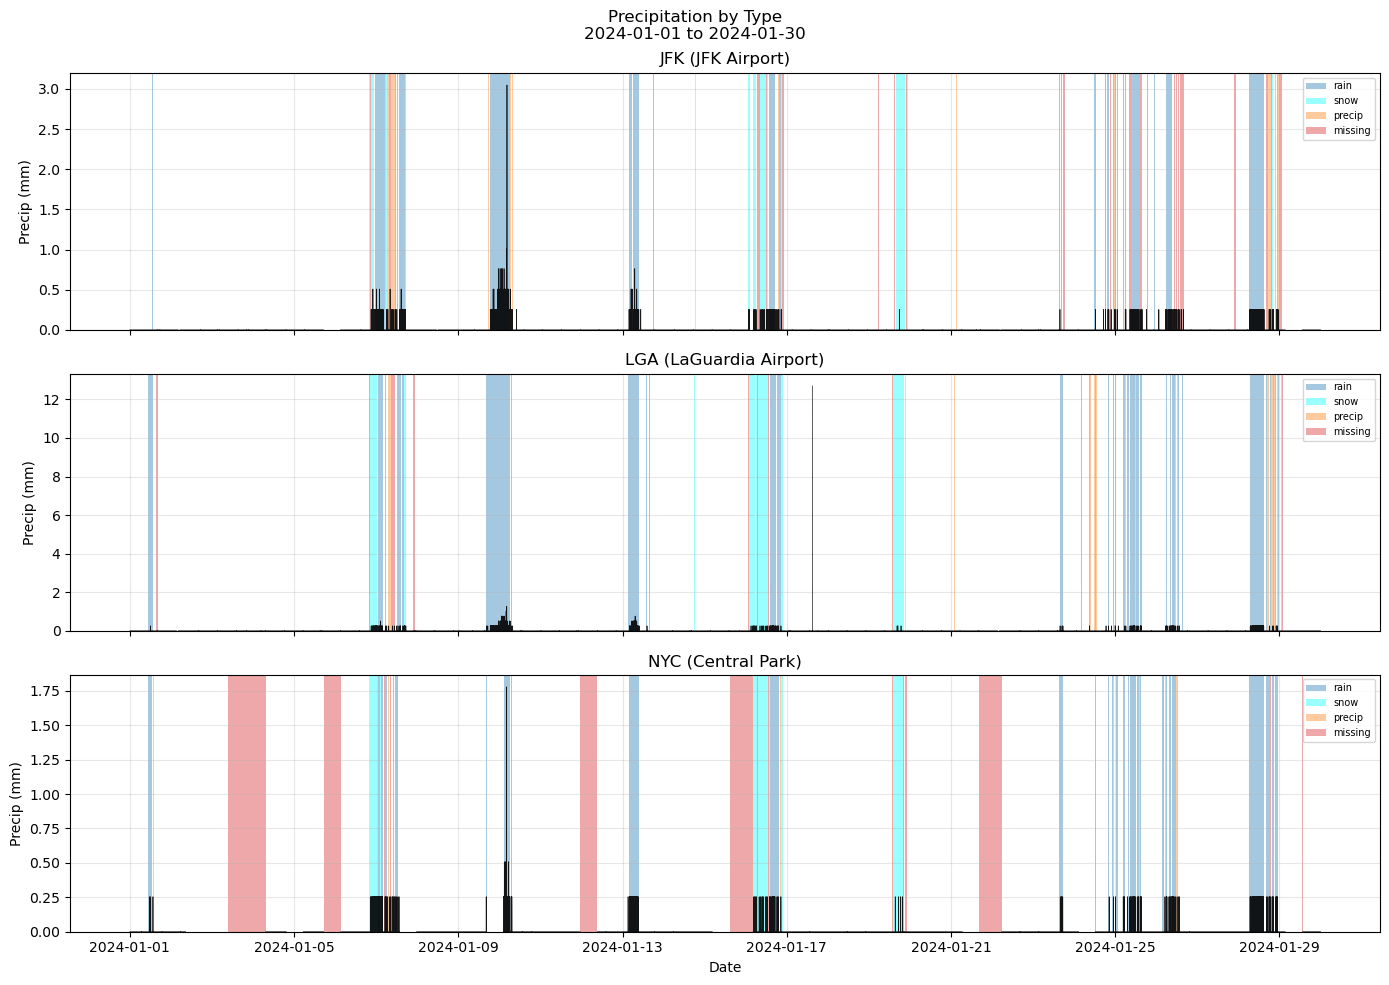

In [24]:
plot_precip_by_type(processed_data, start_date=START_DATE, end_date=END_DATE)

In [25]:
processed_data

{'JFK':                  datetime station_id    temp_c  dewpoint_c  wind_speed_ms  \
 0     2024-01-01 00:00:00        JFK  5.555556   -3.333333        3.60108   
 1     2024-01-01 00:01:00        JFK  5.555556   -3.333333        3.08664   
 2     2024-01-01 00:02:00        JFK  5.555556   -3.333333        4.11552   
 3     2024-01-01 00:03:00        JFK  5.555556   -3.333333        4.11552   
 4     2024-01-01 00:04:00        JFK  5.555556   -3.333333        4.11552   
 ...                   ...        ...       ...         ...            ...   
 40235 2024-01-29 23:55:00        JFK  2.777778   -3.333333        5.65884   
 40236 2024-01-29 23:56:00        JFK  2.777778   -3.333333        5.65884   
 40237 2024-01-29 23:57:00        JFK  2.777778   -3.333333        6.17328   
 40238 2024-01-29 23:58:00        JFK  2.777778   -3.333333        6.68772   
 40239 2024-01-29 23:59:00        JFK  2.777778   -3.333333        6.68772   
 
        wind_dir_deg  wind_gust_ms  wind_gust_dir_deg p

In [26]:
# Cell 7: Resample to custom interval
# Options: '5min', '10min', '15min', '30min', '1H'

RESAMPLE_INTERVAL = '5min'

resampled_data = resample_all_stations(processed_data, interval=RESAMPLE_INTERVAL)

# Check totals still match
print(f"\n{RESAMPLE_INTERVAL} totals (should match 1-min):")
for station_id, df in resampled_data.items():
    total = df['precip_mm'].sum()
    print(f"  {station_id}: {total:.1f} mm")

Resampling to 5min intervals...
  JFK: 8,352 rows
  LGA: 8,352 rows
  NYC: 8,352 rows
✓ Resampling to 5min complete


5min totals (should match 1-min):
  JFK: 147.3 mm
  LGA: 158.2 mm
  NYC: 105.7 mm


In [27]:
# Cell 8: Compute accumulated precipitation
accumulated = compute_accumulated_all(processed_data, START_DATE, END_DATE)

print("Accumulated totals:")
for station_id, df in accumulated.items():
    final = df['accumulated_mm'].iloc[-1]
    print(f"  {station_id}: {final:.1f} mm")

Accumulated totals:
  JFK: 147.3 mm
  LGA: 158.2 mm
  NYC: 105.7 mm


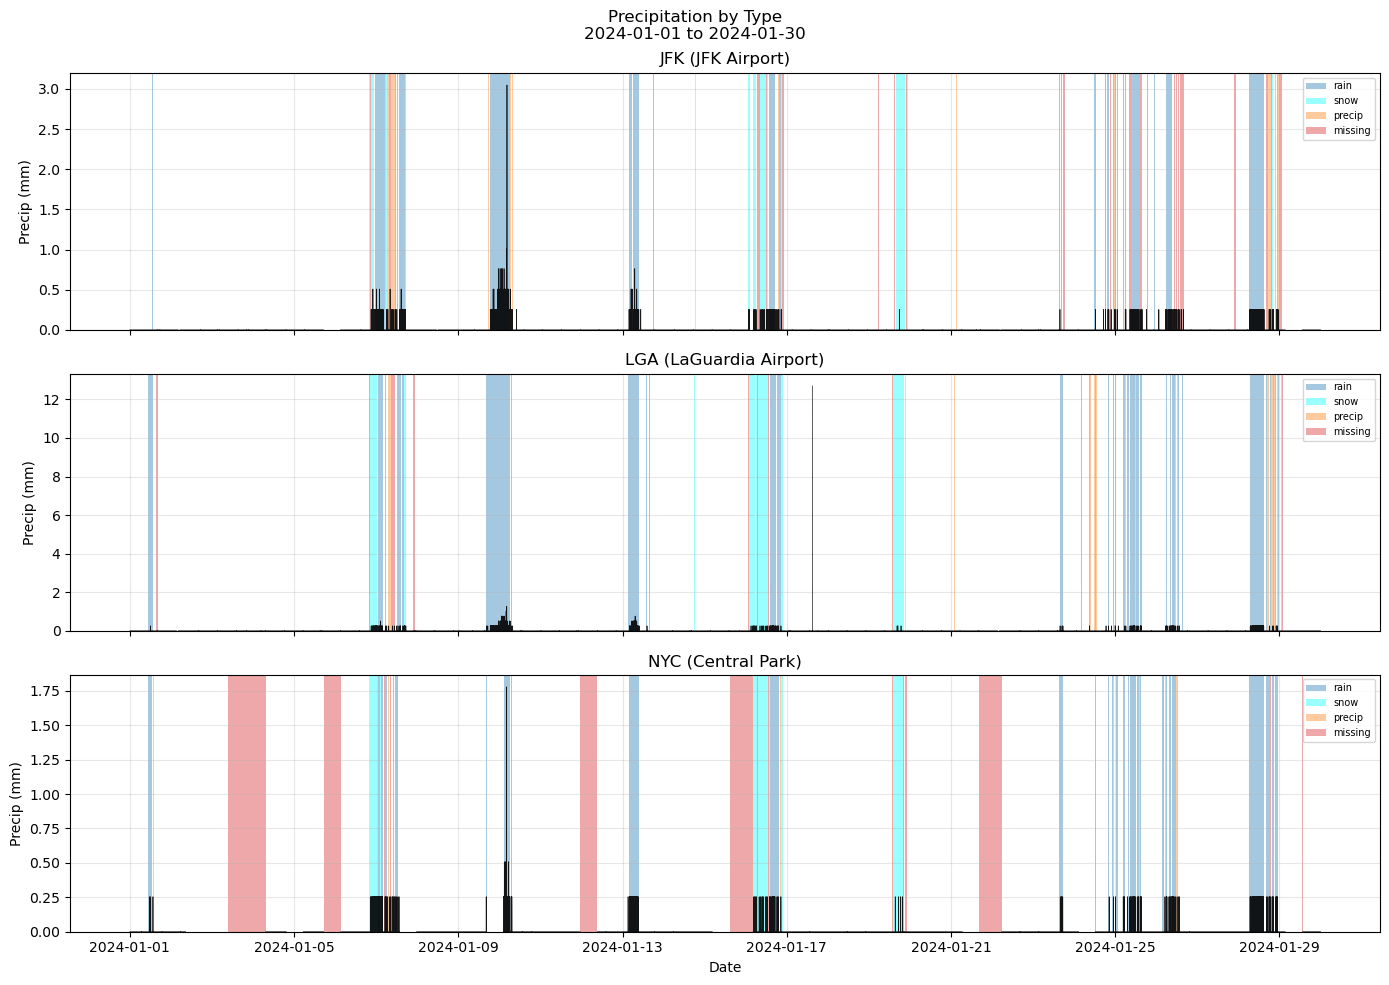

In [28]:
# Cell 10: Plot precipitation by type
fig, axes = plot_precip_by_type(
    processed_data,
    start_date=START_DATE,
    end_date=END_DATE
)
plt.show()

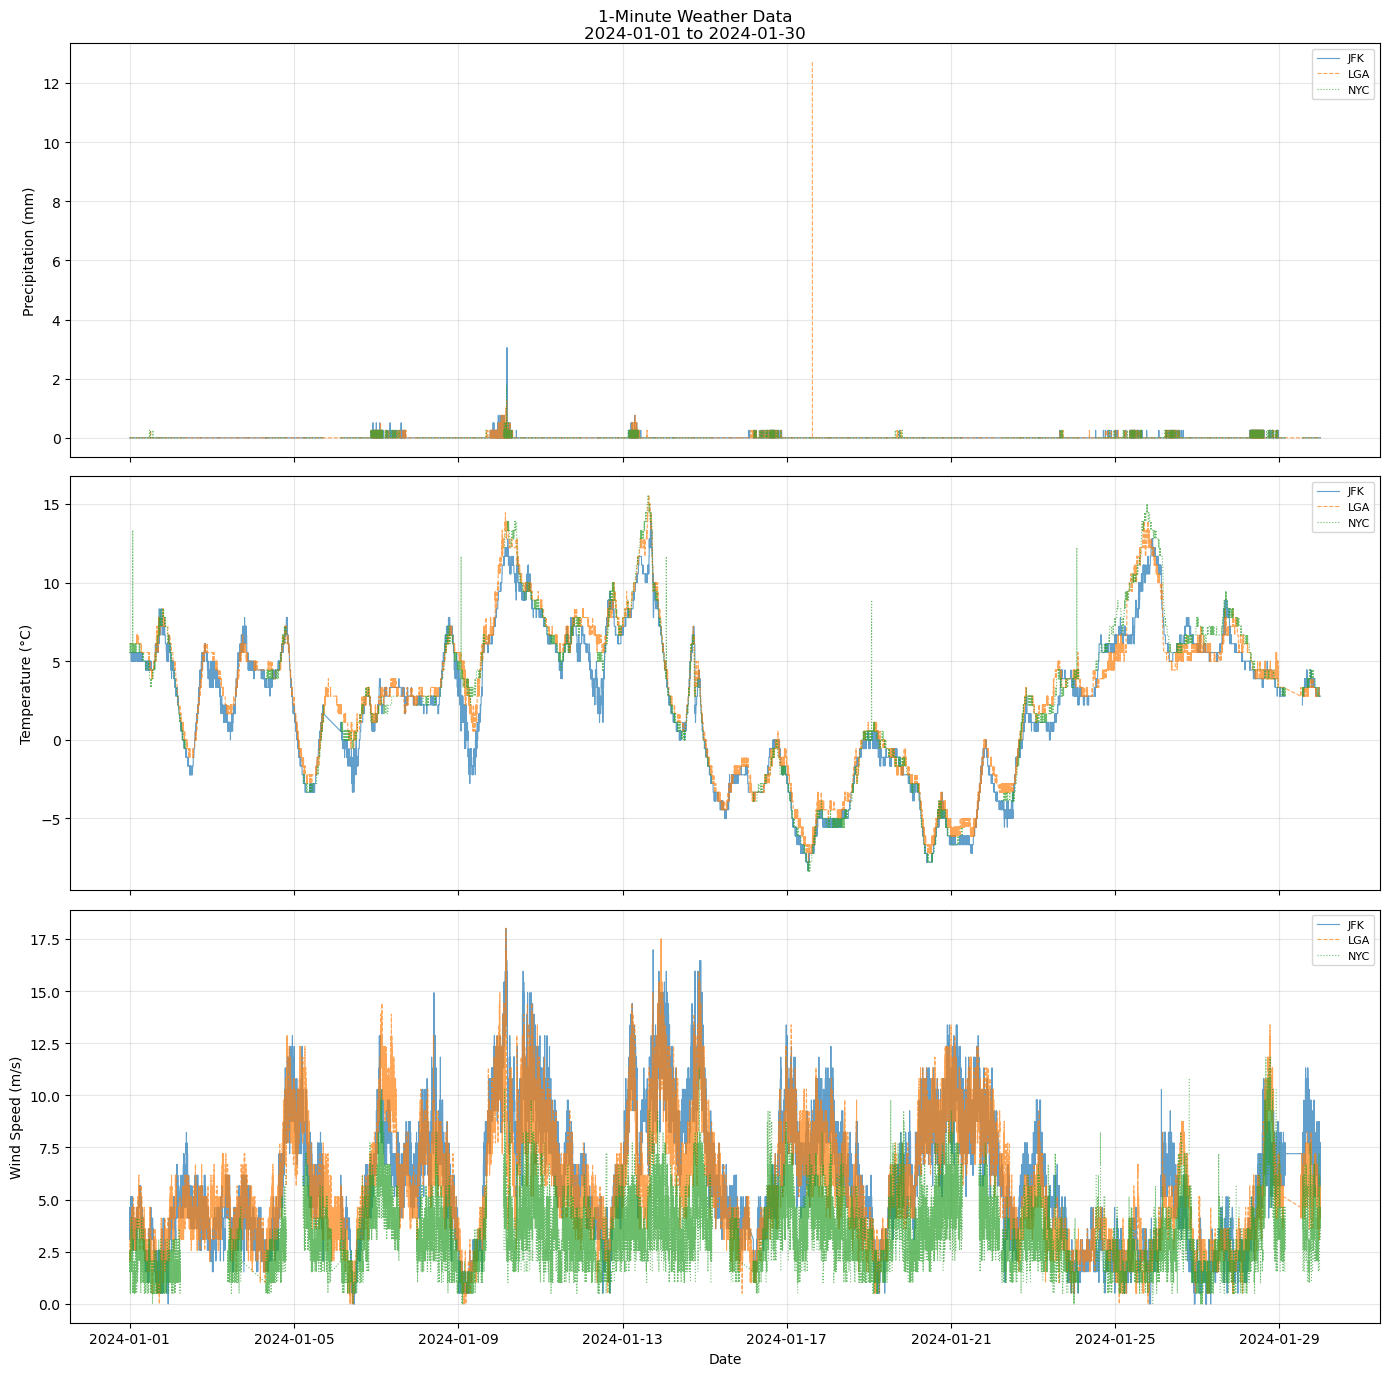

In [29]:
# Cell 11: Plot all weather parameters
fig, axes = plot_weather_subplots(
    processed_data,
    params=['precip_mm', 'temp_c', 'wind_speed_ms'],
    start_date=START_DATE,
    end_date=END_DATE,
    figsize=(14, 14), ylims= [0,5],
    title_prefix='1-Minute' 
)
plt.show()

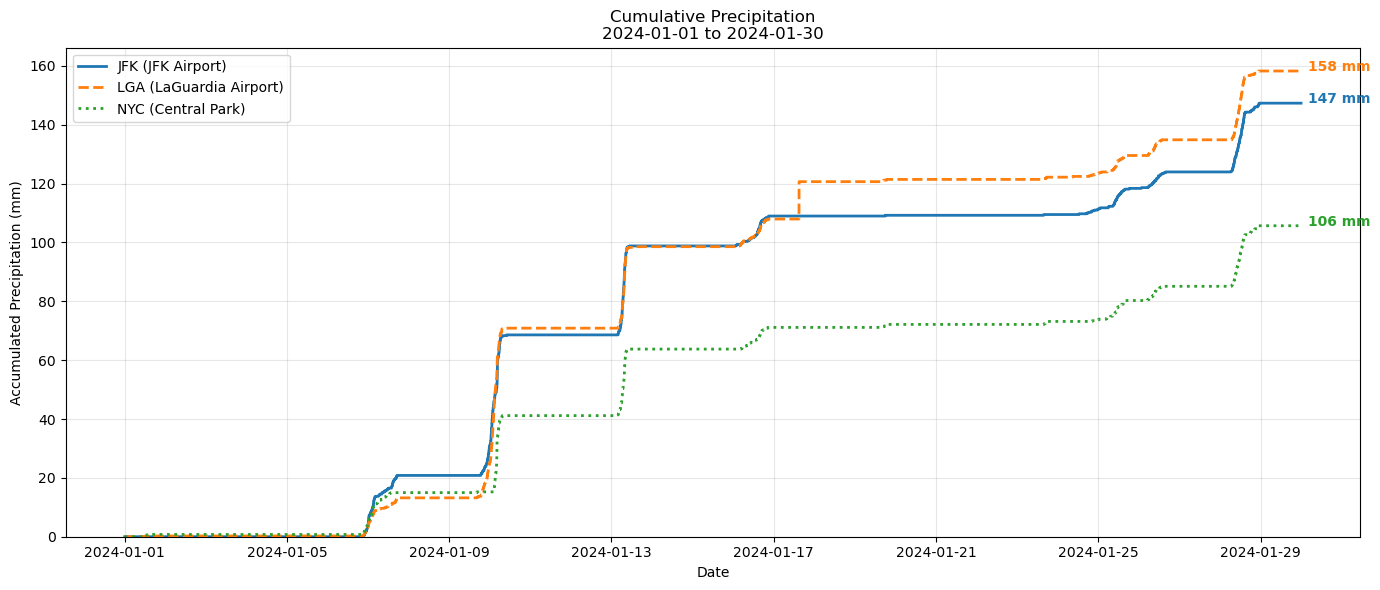

In [30]:
# Cell 12: Plot accumulated precipitation
fig, ax = plot_accumulated(
    accumulated,
    start_date=START_DATE,
    end_date=END_DATE
)
plt.show()

In [31]:
# Cell 13: Save data
# Flags to control what to save
SAVE_1MIN = False
SAVE_RESAMPLED = False
SAVE_INDIVIDUAL = False
SAVE_COMBINED = False

if SAVE_1MIN:
    save_data(
        processed_data, 
        OUTPUT_DIR, 
        prefix='1min',
        save_individual=SAVE_INDIVIDUAL,
        save_combined=SAVE_COMBINED
    )

if SAVE_RESAMPLED:
    save_data(
        resampled_data, 
        OUTPUT_DIR, 
        prefix=RESAMPLE_INTERVAL,
        save_individual=SAVE_INDIVIDUAL,
        save_combined=SAVE_COMBINED
    )

In [32]:
# Cell 14: Summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nPeriod: {START_DATE.date()} to {END_DATE.date()}")
print(f"Stations: {len(processed_data)}")
print(f"Resample interval: {RESAMPLE_INTERVAL}")
print(f"\nVariables: temp_c, dewpoint_c, wind_speed_ms, wind_gust_ms,")
print(f"           wind_dir_deg, visibility_km, precip_type, precip_mm")
print(f"\nPrecipitation totals:")
for station_id, df in processed_data.items():
    total = df['precip_mm'].sum()
    print(f"  {station_id}: {total:.1f} mm")
print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")
print("\n" + "=" * 60)
print("✓ COMPLETE")

SUMMARY

Period: 2024-01-01 to 2024-01-30
Stations: 3
Resample interval: 5min

Variables: temp_c, dewpoint_c, wind_speed_ms, wind_gust_ms,
           wind_dir_deg, visibility_km, precip_type, precip_mm

Precipitation totals:
  JFK: 147.3 mm
  LGA: 158.2 mm
  NYC: 105.7 mm

Output directory: /Users/drorjac/PycharmProjects/OpenMesh-fresh/src/fetch_data/data/noaa_asos

✓ COMPLETE
